In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df=pd.read_csv('Employee_Attrition_Dataset_80_Records.csv')
df.head()

,EmpID,Age,Department,JobRole,YearsAtCompany,JobSatisfaction,WorkLifeBalance,SalarySatisfaction,PromotionOpportunities,StressLevel,LookingForJob,WillLeave,Reason
0,1001,34,Admin,Manager,4,1,1,4,2,2,No,No,NaN
1,1002,22,Finance,Executive,11,5,5,1,3,2,No,No,NaN
2,1003,35,R&D,Supervisor,3,1,3,4,3,4,Yes,No,NaN
3,1004,22,Admin,Developer,9,5,3,2,2,1,Yes,No,NaN
4,1005,25,R&D,Officer,9,2,4,5,5,5,No,No,NaN


In [65]:
df.isnull().sum()

EmpID                      0
Age                        0
Department                 0
JobRole                    0
YearsAtCompany             0
JobSatisfaction            0
WorkLifeBalance            0
SalarySatisfaction         0
PromotionOpportunities     0
StressLevel                0
LookingForJob              0
WillLeave                  0
Reason                    65
dtype: int64

In [66]:
df = df.drop('Reason',axis=1)
df.head()

,EmpID,Age,Department,JobRole,YearsAtCompany,JobSatisfaction,WorkLifeBalance,SalarySatisfaction,PromotionOpportunities,StressLevel,LookingForJob,WillLeave
0,1001,34,Admin,Manager,4,1,1,4,2,2,No,No
1,1002,22,Finance,Executive,11,5,5,1,3,2,No,No
2,1003,35,R&D,Supervisor,3,1,3,4,3,4,Yes,No
3,1004,22,Admin,Developer,9,5,3,2,2,1,Yes,No
4,1005,25,R&D,Officer,9,2,4,5,5,5,No,No


In [67]:
df.describe()

,EmpID,Age,YearsAtCompany,JobSatisfaction,WorkLifeBalance,SalarySatisfaction,PromotionOpportunities,StressLevel
count,80.0000,80.000000,80.000000,80.000000,80.00000,80.000000,80.000000,80.000000
mean,1040.5000,34.987500,7.275000,2.850000,2.78750,2.712500,2.762500,2.825000
std,23.2379,8.171413,3.738188,1.397104,1.51527,1.424858,1.425303,1.421133
min,1001.0000,22.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000
25%,1020.7500,27.750000,4.000000,2.000000,1.00000,2.000000,1.000000,2.000000
50%,1040.5000,34.000000,7.500000,3.000000,2.00000,2.000000,3.000000,2.500000
75%,1060.2500,40.000000,10.000000,4.000000,4.00000,4.000000,4.000000,4.000000
max,1080.0000,50.000000,15.000000,5.000000,5.00000,5.000000,5.000000,5.000000


In [68]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first')

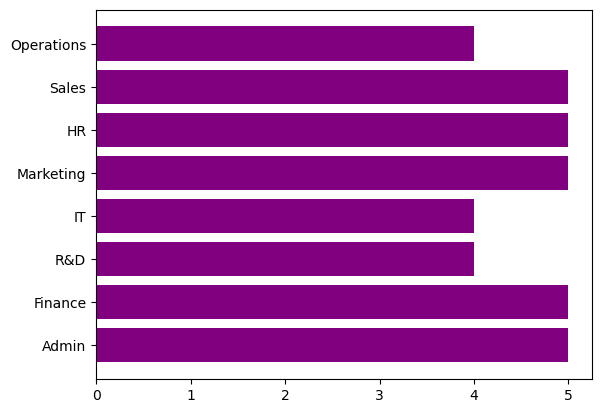

In [69]:
plt.barh(df.Department,df.JobSatisfaction,color='purple')
plt.show()

In [70]:
df.groupby('Department')['JobSatisfaction'].mean().reset_index()

,Department,JobSatisfaction
0,Admin,3.250000
1,Finance,3.300000
2,HR,3.000000
3,IT,2.923077
4,Marketing,3.333333
5,Operations,2.375000
6,R&D,1.818182
7,Sales,2.714286


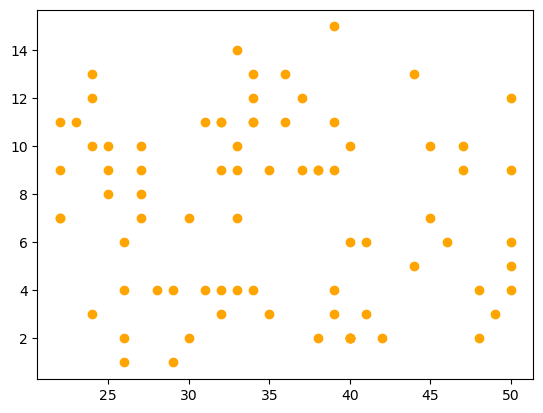

In [71]:
plt.scatter(df.Age,df.YearsAtCompany,color='orange')
plt.show()

In [72]:
print(round(df.JobSatisfaction.corr(df.StressLevel),2))
print(round(df.SalarySatisfaction.corr(df.StressLevel),2))
print(round(df.SalarySatisfaction.corr(df.StressLevel),2))
print(round(df.PromotionOpportunities.corr(df.Age),2))

-0.05
-0.09
-0.09
-0.2


In [73]:
df2=pd.get_dummies(data=df,columns=['Department','JobRole'],drop_first = True,dtype=int)
df2.head(10)

,EmpID,Age,YearsAtCompany,JobSatisfaction,WorkLifeBalance,SalarySatisfaction,PromotionOpportunities,StressLevel,LookingForJob,WillLeave,...,Department_Operations,Department_R&D,Department_Sales,JobRole_Developer,JobRole_Engineer,JobRole_Executive,JobRole_Manager,JobRole_Officer,JobRole_Scientist,JobRole_Supervisor
0,1001,34,4,1,1,4,2,2,No,No,...,0,0,0,0,0,0,1,0,0,0
1,1002,22,11,5,5,1,3,2,No,No,...,0,0,0,0,0,1,0,0,0,0
2,1003,35,3,1,3,4,3,4,Yes,No,...,0,1,0,0,0,0,0,0,0,1
3,1004,22,9,5,3,2,2,1,Yes,No,...,0,0,0,1,0,0,0,0,0,0
4,1005,25,9,2,4,5,5,5,No,No,...,0,1,0,0,0,0,0,1,0,0
5,1006,36,13,4,2,2,3,3,Yes,Yes,...,0,0,0,0,0,0,0,0,0,1
6,1007,40,2,1,5,3,1,2,Yes,Yes,...,0,1,0,1,0,0,0,0,0,0
7,1008,38,2,3,1,4,3,4,Yes,No,...,0,0,0,1,0,0,0,0,0,0
8,1009,33,10,2,3,3,1,4,No,No,...,0,0,0,0,0,1,0,0,0,0
9,1010,24,10,1,1,4,1,1,No,No,...,0,1,0,0,0,0,1,0,0,0


In [74]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [75]:
df2['LookingForJob']=le.fit_transform(df2['LookingForJob'])
df2['WillLeave']=le.fit_transform(df2['WillLeave'])

In [76]:
df2.head()

,EmpID,Age,YearsAtCompany,JobSatisfaction,WorkLifeBalance,SalarySatisfaction,PromotionOpportunities,StressLevel,LookingForJob,WillLeave,...,Department_Operations,Department_R&D,Department_Sales,JobRole_Developer,JobRole_Engineer,JobRole_Executive,JobRole_Manager,JobRole_Officer,JobRole_Scientist,JobRole_Supervisor
0,1001,34,4,1,1,4,2,2,0,0,...,0,0,0,0,0,0,1,0,0,0
1,1002,22,11,5,5,1,3,2,0,0,...,0,0,0,0,0,1,0,0,0,0
2,1003,35,3,1,3,4,3,4,1,0,...,0,1,0,0,0,0,0,0,0,1
3,1004,22,9,5,3,2,2,1,1,0,...,0,0,0,1,0,0,0,0,0,0
4,1005,25,9,2,4,5,5,5,0,0,...,0,1,0,0,0,0,0,1,0,0


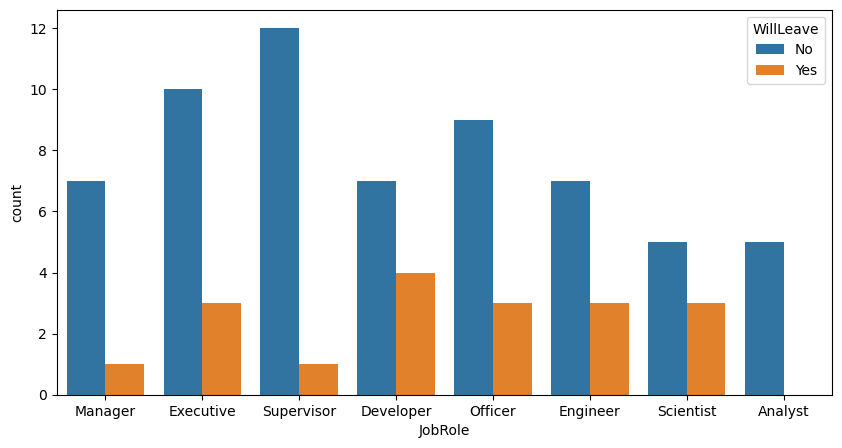

In [77]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x="JobRole",hue="WillLeave")
plt.show()

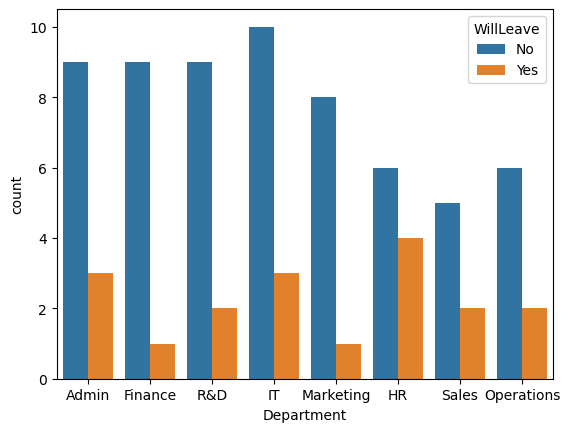

In [78]:
sns.countplot(data=df,x="Department",hue="WillLeave")
plt.show()

In [79]:
df2 = df2.drop('EmpID',axis=1)

In [80]:
df2

,Age,YearsAtCompany,JobSatisfaction,WorkLifeBalance,SalarySatisfaction,PromotionOpportunities,StressLevel,LookingForJob,WillLeave,Department_Finance,...,Department_Operations,Department_R&D,Department_Sales,JobRole_Developer,JobRole_Engineer,JobRole_Executive,JobRole_Manager,JobRole_Officer,JobRole_Scientist,JobRole_Supervisor
0,34,4,1,1,4,2,2,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,22,11,5,5,1,3,2,0,0,1,...,0,0,0,0,0,1,0,0,0,0
2,35,3,1,3,4,3,4,1,0,0,...,0,1,0,0,0,0,0,0,0,1
3,22,9,5,3,2,2,1,1,0,0,...,0,0,0,1,0,0,0,0,0,0
4,25,9,2,4,5,5,5,0,0,0,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,38,9,2,2,5,5,2,1,0,0,...,1,0,0,0,0,0,0,0,0,0
76,22,7,4,2,1,2,2,0,0,0,...,0,0,0,0,0,0,0,1,0,0
77,36,11,4,5,3,3,4,0,0,0,...,0,0,0,0,0,0,0,0,0,1
78,33,9,2,1,5,3,2,1,1,0,...,0,0,0,1,0,0,0,0,0,0


In [81]:
x = df2.drop('WillLeave',axis=1)
y = df2['WillLeave']

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
lr = LogisticRegression()

In [83]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [84]:
lr.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [85]:
pred = lr.predict(x_test)

In [86]:
pred.shape

(20,)

In [87]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report,auc,pair_confusion_matrix,confusion_matrix

In [88]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        18
           1       0.50      0.50      0.50         2

    accuracy                           0.90        20
   macro avg       0.72      0.72      0.72        20
weighted avg       0.90      0.90      0.90        20



In [89]:
accuracy_score(y_test,pred)

0.9

In [90]:
precision_score(y_test,pred)

0.5

In [91]:
recall_score(y_test,pred)

0.5

In [92]:
cm=confusion_matrix(y_test,pred)
cm

array([[17,  1],
       [ 1,  1]])

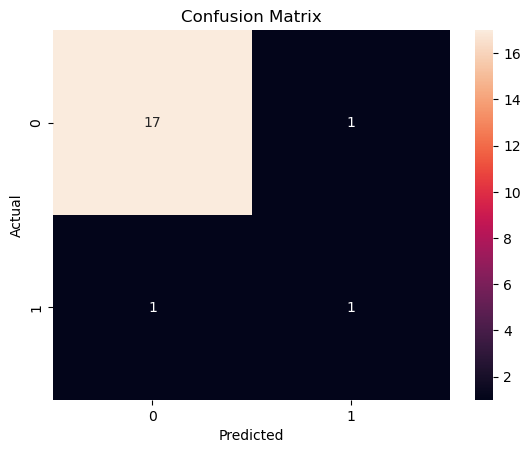

In [93]:
sns.heatmap(cm,annot=True,fmt='d',cmap='rocket')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [94]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [95]:
pred1=dt.predict(x_test)

In [96]:
accuracy_score(y_test,pred1)

0.9

In [97]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [98]:
pred2=rf.predict(x_test)
pred2

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [99]:
recall_score(y_test,pred2)

0.0

In [100]:
print(classification_report(y_test,pred2))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95        18
           1       0.00      0.00      0.00         2

    accuracy                           0.90        20
   macro avg       0.45      0.50      0.47        20
weighted avg       0.81      0.90      0.85        20



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
